# Dataset statistics

Count and group-by queries with matplotlib charts. Use this
notebook to get a feel for how the corpus is distributed across
agent types, ego actions, and environments before you go
looking for specific scenarios.

> See `01_quickstart.ipynb` for an introduction to the dataset
> and `02_query_dsl_tour.ipynb` for the query language itself.


## Setup


In [1]:
import os
from collections import Counter
from pathlib import Path

from cascade_av.dataset import CascadeDataset
from cascade_av.query.constants import (
    ALIAS_FAMILIES,           # registry — keyed by family name
    AGENT_TYPE_PARENTS,       # vehicle / cyclist / ped / vru
    ACTION_TYPE_PARENTS,      # turn / stop_yield_decel
    ENV_TYPE_PARENTS,         # intersection / shoulder
    OBJ_TYPE_PARENTS,         # sign / debris / barrier
)

# --- shared notebook styling -----------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

pd.options.display.max_colwidth = 110
pd.options.display.width = 140
pd.options.display.float_format = "{:.2f}".format


In [2]:
ds = CascadeDataset(Path(os.environ["CASCADE_AV_DATASET_ROOT"]))
print(f"corpus loaded — {len(ds)} clips")


def entity_count(query: str) -> int:
    """Number of matching *entities* across the corpus (not clips)."""
    return len(ds.find(query).matches)


def entities_by_attr(query: str, attr: str) -> dict:
    """Bucket matching entities by a top-level attribute (e.g. ``type``).

    Like ``ds.group_by`` but counts entities rather than clips.
    """
    out = Counter()
    for m in ds.find(query).matches:
        val = getattr(m.entity, attr, None)
        if isinstance(val, list):
            for v in val:
                out[v] += 1
        else:
            out[val] += 1
    return dict(out)


def actions_with_suffix(query: str, suffix: str) -> int:
    """Number of matching *action* entities whose ``action_type`` (or
    ego ``type``) contains ``suffix`` as a parenthesized-suffix token.

    Schema 2.0.0 encodes flags inside the type string —
    ``oxd:Walk (jaywalk)``, ``oxd:Walk (jaywalk, erratic)``,
    ``oxd:MakeARightTurn (unprotected)``. Tokens inside the
    parentheses are comma-separated; this helper matches a single
    token (``"jaywalk"``, ``"erratic"``, ``"unprotected"``).

    Example::

        actions_with_suffix("agent(type = ped, action.type = walk)",
                            "jaywalk")
    """
    suffix = suffix.strip().lower()
    out = 0
    for m in ds.find(query).matches:
        type_str = (
            getattr(m.entity, "action_type", None)
            or getattr(m.entity, "type", "")
            or ""
        )
        if "(" not in type_str or not type_str.endswith(")"):
            continue
        inside = type_str[type_str.index("(") + 1 : -1]
        tokens = [t.strip().lower() for t in inside.split(",")]
        if suffix in tokens:
            out += 1
    return out


# --- vocabulary-driven distribution helpers --------------------------------
# Drive every distribution chart from `cascade_av.query.constants` so new
# schema values appear automatically without editing the notebook.

_PARENT_MAPS = {
    "agent_type":  AGENT_TYPE_PARENTS,
    "action_type": ACTION_TYPE_PARENTS,
    "env_type":    ENV_TYPE_PARENTS,
    "obj_type":    OBJ_TYPE_PARENTS,
}


def leaves_for(family: str) -> list[str]:
    """Vocabulary leaves only — strips parent aliases (which are unions of leaves)."""
    parents = _PARENT_MAPS.get(family, {})
    return [k for k in ALIAS_FAMILIES[family] if k not in parents]


def parents_for(family: str) -> list[str]:
    """Parent aliases for a family (empty list for families with no hierarchy)."""
    return list(_PARENT_MAPS.get(family, {}))


def distribution(key: str, family: str) -> pd.DataFrame:
    """Clip + entity counts for every leaf of `family`, bucketed by DSL `key`.

    Examples:
        distribution("agent.type",        "agent_type")
        distribution("ego.action.type",   "action_type")
        distribution("agent.action.type", "action_type")
        distribution("env.type",          "env_type")
        distribution("obj.type",          "obj_type")
        distribution("light.color",       "light_color")
        distribution("light.state",       "light_state")
        distribution("light.shape",       "light_shape")
        distribution("cond.type",         "cond_type")
        distribution("ego.judgment",      "driving_judgment")
    """
    # Query per leaf so we drive the chart on alias labels ("car", "truck")
    # rather than raw schema strings ("oxd:Car", "PublicBus") that
    # ds.group_by exposes. Cost: 2N queries instead of 2, but N <= 24 leaves
    # and each query is a fast in-memory tree walk.
    leaves = leaves_for(family)
    clips    = {leaf: ds.count(f"{key} = {leaf}")    for leaf in leaves}
    entities = {leaf: entity_count(f"{key} = {leaf}") for leaf in leaves}
    df = pd.DataFrame({
        "clips":    pd.Series(clips,    index=leaves),
        "entities": pd.Series(entities, index=leaves),
    }).fillna(0).astype(int)
    return df.sort_values("entities", ascending=True)


def parent_rollup(key: str, family: str) -> pd.Series:
    """Clip count per parent alias (one DSL query per parent)."""
    parents = parents_for(family)
    if not parents:
        return pd.Series(dtype=int)
    return pd.Series(
        {p: ds.count(f"{key} = {p}") for p in parents},
        name="clips",
    ).sort_values(ascending=False)


def distribution_chart(
    key: str,
    family: str,
    title: str,
    *,
    color: str = "#3b6ea5",
    color_light: str = "#8aa6c8",
) -> pd.DataFrame:
    """Standard distribution chart: horizontal grouped bars (clips + entities).

    Each bar is annotated with its numeric value at the end of the bar —
    axis ticks alone make it hard to read exact counts when bars are short.
    """
    df = distribution(key, family)
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(df) + 1.5))
    y = range(len(df))
    bars_clips    = ax.barh([i + 0.2 for i in y], df["clips"],    height=0.4, color=color,       label="clips")
    bars_entities = ax.barh([i - 0.2 for i in y], df["entities"], height=0.4, color=color_light, label="entities")
    # Hide zero-valued labels — they clutter the chart and the empty bar
    # at the axis is already self-evident.
    clip_labels = [str(int(v)) if v else "" for v in df["clips"]]
    ent_labels  = [str(int(v)) if v else "" for v in df["entities"]]
    ax.bar_label(bars_clips,    labels=clip_labels, padding=3, fontsize=9)
    ax.bar_label(bars_entities, labels=ent_labels,  padding=3, fontsize=9)
    ax.set_yticks(list(y))
    ax.set_yticklabels(df.index)
    ax.set_xlabel("count")
    ax.set_title(title)
    # Pad the x-axis so end-of-bar labels don't clip on the right edge.
    xmax = max(df.values.max(), 1)
    ax.set_xlim(0, xmax * 1.08)
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()
    return df


corpus loaded — 344 clips


/home/horde/Projects/av-causal-dataset-tools-feat-annotator-2.0.0/src/cascade_av/dataset.py:118: UserWarning: 1 clip_id(s) had multiple annotation files; kept first by filename. (Set CASCADE_AV_VERBOSE=1 for per-file detail.)
  self._scan(annotation_paths, annotation_root)


## Clips vs entities

The query API exposes two complementary perspectives:

- **`ds.count(query)`** — the number of *clips* with ≥1 match.
  Tells you about *coverage*: "how many clips even contain
  this thing?"
- **`len(ds.find(query).matches)`** — the number of *matching
  entities*. Tells you about *prevalence*: "how often does
  this thing occur?" A single clip can contribute many
  entities (six pedestrians, four vehicles, …).

Both are useful — coverage tells you how varied the corpus
is; prevalence tells you the actual instance counts.


## Headline counts

Per-namespace summary of the corpus. One row per entity family —
how many clips contain ≥1 leaf of that family, how many entities
in total, and the three leaves contributing the most entities.
Pulled from `cascade_av.query.constants.ALIAS_FAMILIES` so the
summary stays correct when the schema gains a new leaf.

In [3]:
NAMESPACES = [
    ("agent.type",   "agent_type"),
    ("env.type",     "env_type"),
    ("obj.type",     "obj_type"),
    ("light.color",  "light_color"),
    ("cond.type",    "cond_type"),
    ("ego.judgment", "driving_judgment"),
]

rows = []
for key, family in NAMESPACES:
    df = distribution(key, family)
    leaves = " or ".join(f"{key} = {leaf}" for leaf in df.index)
    total_clips = ds.count(leaves)
    top3 = df.sort_values("entities", ascending=False).head(3).index.tolist()
    rows.append({
        "family":        family,
        "DSL key":       key,
        "leaves":        len(df),
        "clips (any)":   total_clips,
        "entities":      int(df["entities"].sum()),
        "top 3 leaves":  ", ".join(top3),
    })
headline = pd.DataFrame(rows)
headline

,family,DSL key,leaves,clips (any),entities,top 3 leaves
0,agent_type,agent.type,16,329,1384,"car, ped_adult, truck"
1,env_type,env.type,20,344,1636,"road, crosswalk, sidewalk"
2,obj_type,obj.type,24,302,1592,"traffic_sign, other, cone"
3,light_color,light.color,4,150,331,"green, red, yellow"
4,cond_type,cond.type,9,157,377,"construction, lanes_obscured, wet"
5,driving_judgment,ego.judgment,3,311,311,"good, neutral, bad"


## Distribution of agent types

All 15 leaf kinds in the `agent_type` vocabulary. Parents
(`vehicle`, `cyclist`, `ped`, `vru`) are summarised in the small
table below the chart — each parent is the union of its leaves
and would double-count if mixed into the same bars.

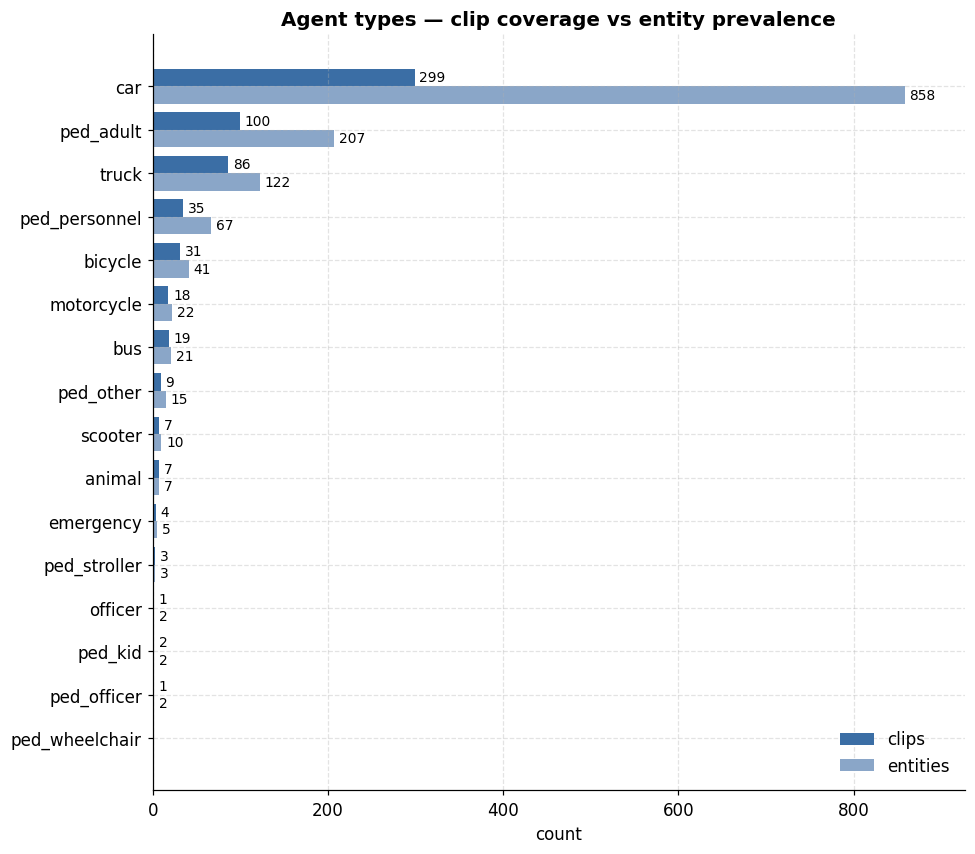

,parent
vehicle,313
vru,144
ped,133
cyclist,34


In [4]:
agent_df = distribution_chart("agent.type", "agent_type",
                              "Agent types — clip coverage vs entity prevalence")

# Parent rollup (clip-level only — entities-per-parent doesn't help here
# because a single clip can satisfy multiple leaves under the same parent).
pd.DataFrame({"parent": parent_rollup("agent.type", "agent_type")})

## Distribution of agent actions

Action vocabulary applied to **other agents** (`agent.action.type`).
All 24 leaves; parents (`turn`, `stop_yield_decel`) are summarised
below the chart.

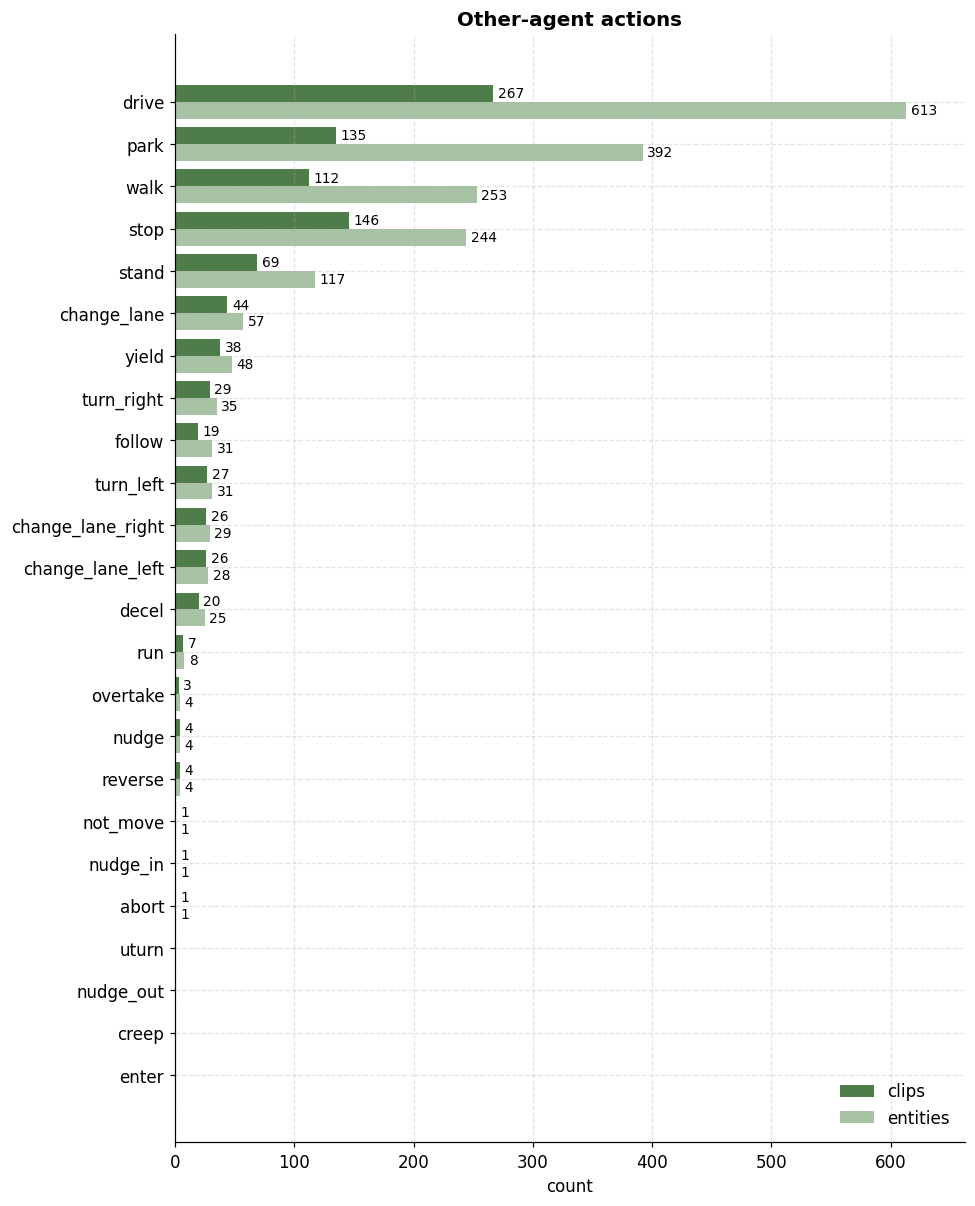

,parent
stop_yield_decel,169
turn,51


In [5]:
agent_action_df = distribution_chart("agent.action.type", "action_type",
                                     "Other-agent actions",
                                     color="#4f7d4a", color_light="#a8c2a5")
pd.DataFrame({"parent": parent_rollup("agent.action.type", "action_type")})

## Distribution of ego actions

Same vocabulary as agent actions but applied to **ego**
(`ego.action.type`). Compare against the previous chart to see
which actions are ego-only or agent-only in this corpus.

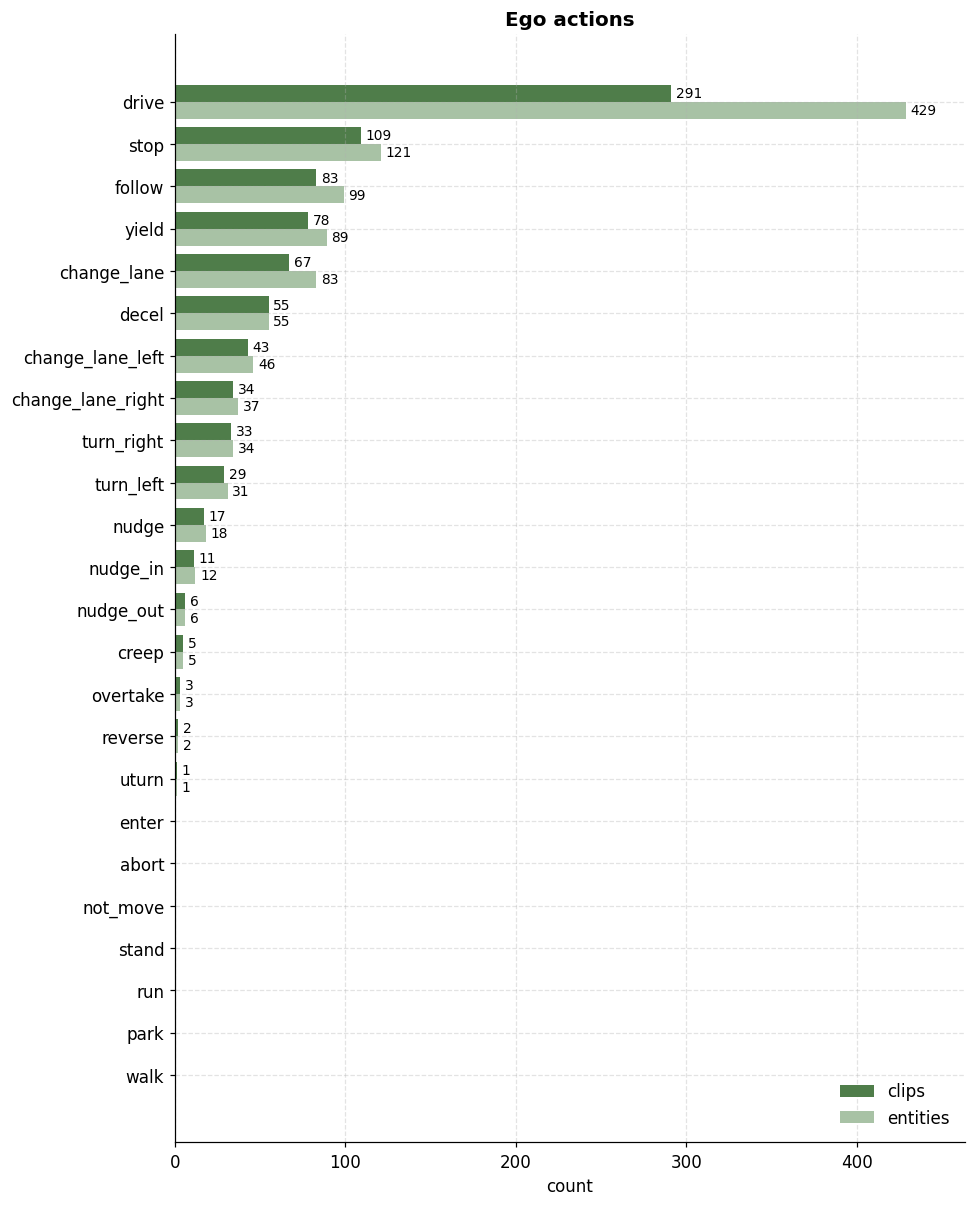

,parent
stop_yield_decel,197
turn,62


In [6]:
ego_action_df = distribution_chart("ego.action.type", "action_type",
                                   "Ego actions",
                                   color="#4f7d4a", color_light="#a8c2a5")
pd.DataFrame({"parent": parent_rollup("ego.action.type", "action_type")})

## Distribution of environment types

All leaves in the `env_type` vocabulary. Parents (`intersection`,
`shoulder`) below the chart roll the specific intersection /
shoulder leaves into their family totals.

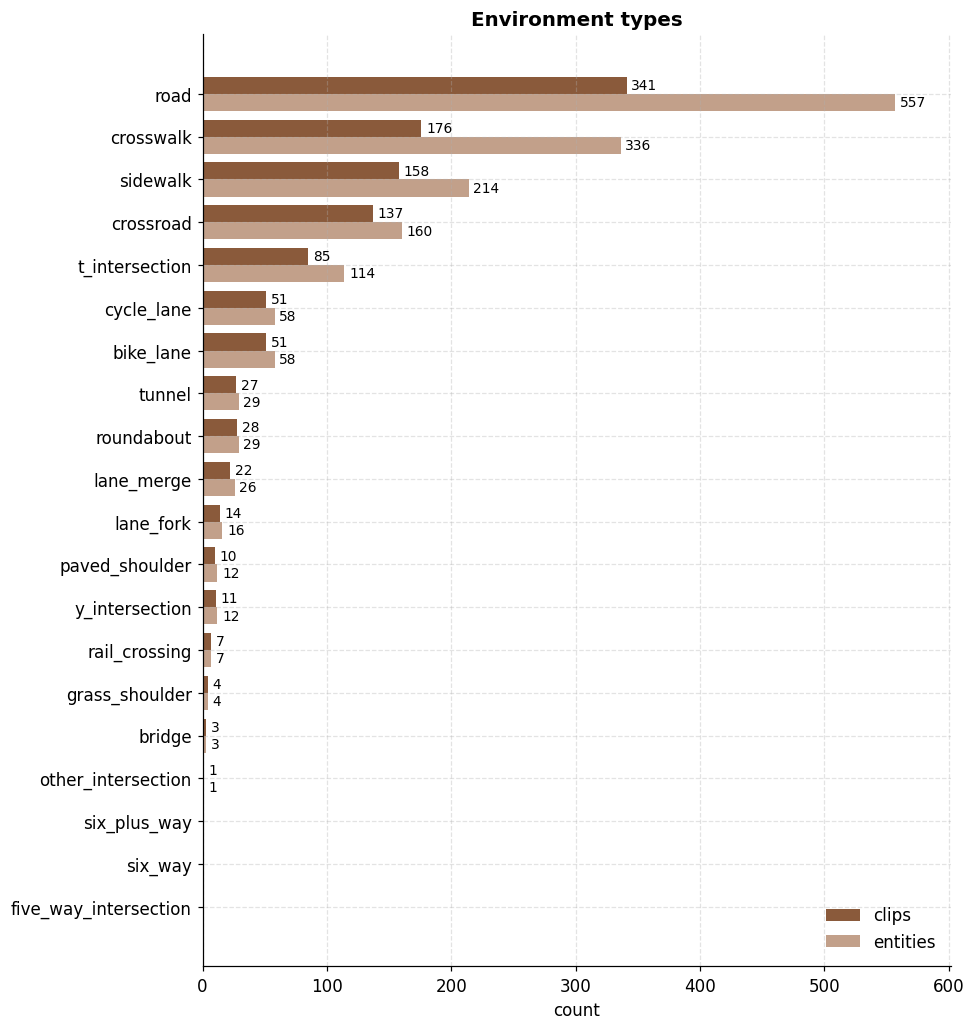

,parent
intersection,210
shoulder,13


In [7]:
env_df = distribution_chart("env.type", "env_type",
                            "Environment types",
                            color="#8a5a3b", color_light="#c2a08a")
pd.DataFrame({"parent": parent_rollup("env.type", "env_type")})

## Distribution of environmental conditions

Per-clip weather, lighting, and road-state via the `cond` entity
(`clear` / `wet` / `snowy` / `construction` / `temp_marked`).
Tells you the mix of operating conditions in the corpus.

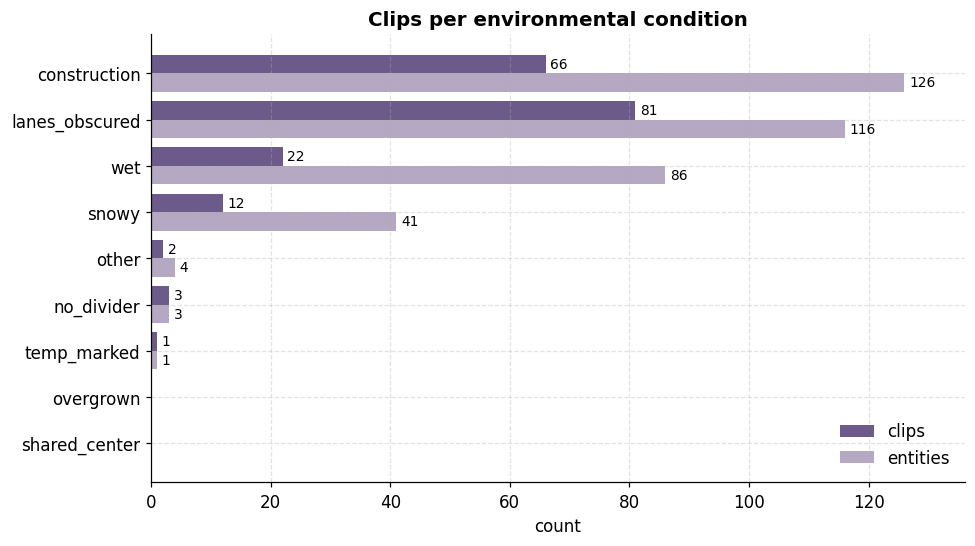

,clips,entities
shared_center,0,0
overgrown,0,0
temp_marked,1,1
no_divider,3,3
other,2,4
snowy,12,41
wet,22,86
lanes_obscured,81,116
construction,66,126


In [8]:
cond_df = distribution_chart("cond.type", "cond_type",
                             "Clips per environmental condition",
                             color="#6b5a8a", color_light="#b5a8c2")
cond_df

## Distribution of traffic objects

Every leaf in the `obj_type` vocabulary (signs, debris, barriers,
portable displays, etc.). Parents below the chart roll the
leaves into their three families: `sign` / `debris` / `barrier`.

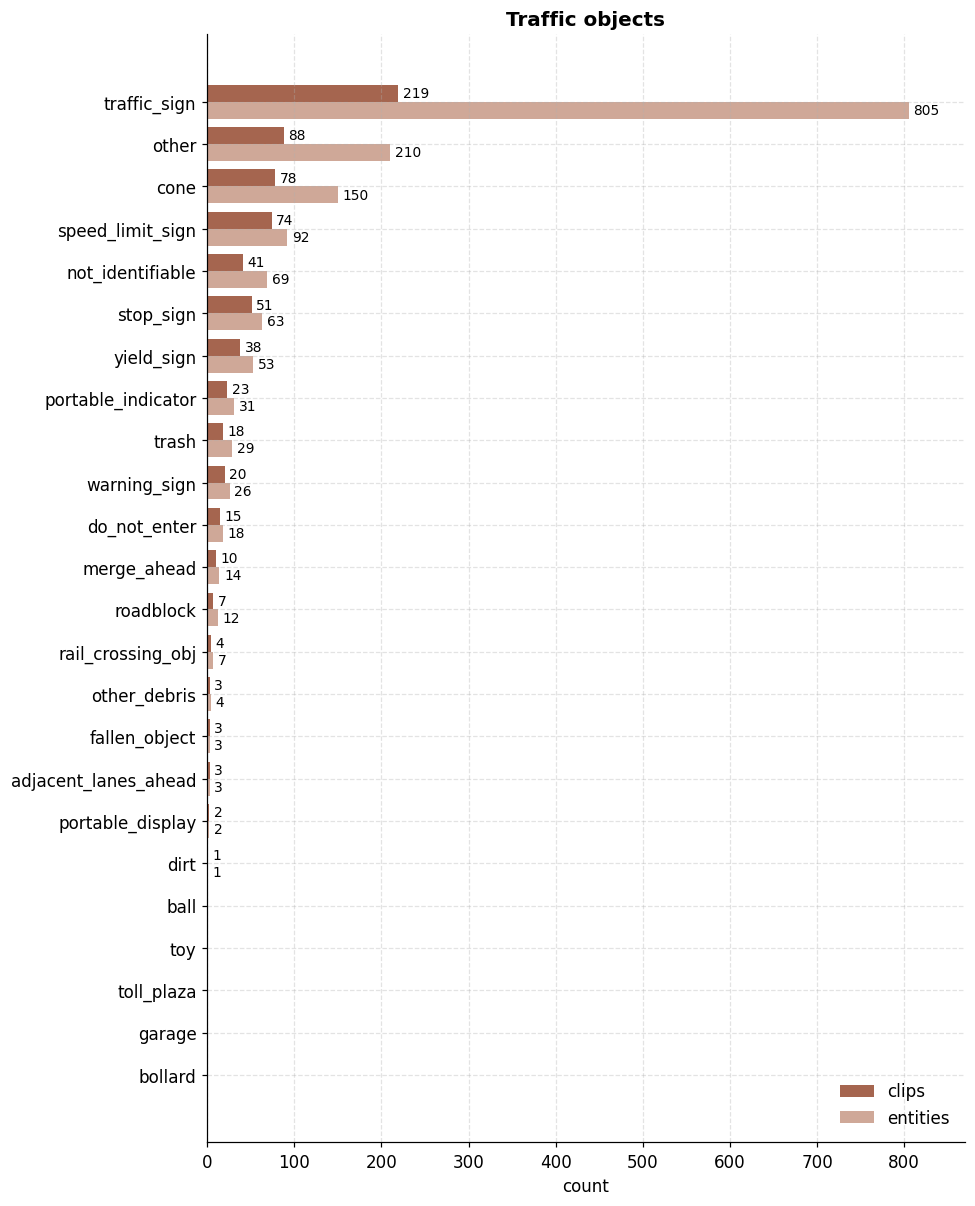

,parent
sign,258
barrier,83
debris,21
fallen,3


In [9]:
obj_df = distribution_chart("obj.type", "obj_type",
                            "Traffic objects",
                            color="#a5654f", color_light="#cfa898")
pd.DataFrame({"parent": parent_rollup("obj.type", "obj_type")})

## Distribution of traffic lights

Three small charts — `light.color`, `light.state`, `light.shape`
— side by side. Use them together to find specific light
configurations (e.g. flashing red arrows).

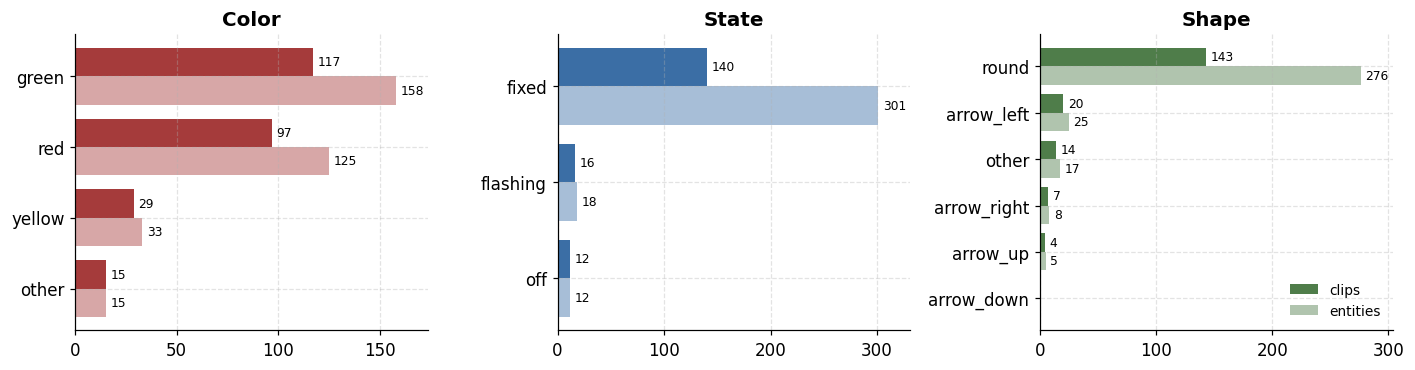

In [10]:
import matplotlib.colors as mcolors

def _lighten(c, alpha=0.45):
    r, g, b = mcolors.to_rgb(c)
    return (r + (1 - r) * (1 - alpha),
            g + (1 - g) * (1 - alpha),
            b + (1 - b) * (1 - alpha))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (key, family, title, c) in zip(axes, [
    ("light.color", "light_color", "Color", "#a53b3b"),
    ("light.state", "light_state", "State", "#3b6ea5"),
    ("light.shape", "light_shape", "Shape", "#4f7d4a"),
]):
    df = distribution(key, family)
    y = range(len(df))
    bars_c = ax.barh([i + 0.2 for i in y], df["clips"],    height=0.4, color=c,             label="clips")
    bars_e = ax.barh([i - 0.2 for i in y], df["entities"], height=0.4, color=_lighten(c),   label="entities")
    clip_labels = [str(int(v)) if v else "" for v in df["clips"]]
    ent_labels  = [str(int(v)) if v else "" for v in df["entities"]]
    ax.bar_label(bars_c, labels=clip_labels, padding=3, fontsize=8)
    ax.bar_label(bars_e, labels=ent_labels,  padding=3, fontsize=8)
    ax.set_yticks(list(y))
    ax.set_yticklabels(df.index)
    ax.set_title(title)
    xmax = max(df.values.max(), 1)
    ax.set_xlim(0, xmax * 1.10)
axes[-1].legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Distribution of driving judgment

Ego's self-reported driving judgment per clip
(`good` / `acceptable` / `neutral` / `bad`). One value per clip
so the entities and clips bars match exactly.

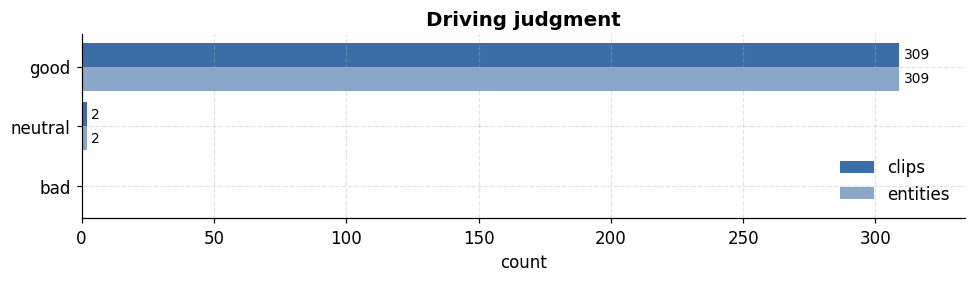

,clips,entities
bad,0,0
neutral,2,2
good,309,309


In [11]:
judgment_df = distribution_chart("ego.judgment", "driving_judgment",
                                 "Driving judgment",
                                 color="#3b6ea5", color_light="#8aa6c8")
judgment_df

## Composite questions

DSL queries compose, so you can pose questions that combine
primitives — for example, "of the clips that contain a red
light, what fraction also contain an ego stop?"


In [12]:
def cond_row(label: str, pop_query: str, sub_query: str):
    """One row of the composite-questions table: (label, n_sub, n_pop, n_sub/n_pop)."""
    pop = ds.count(pop_query)
    sub = ds.count(sub_query)
    return (label, sub, pop, sub / max(pop, 1))


# Schema 2.0.0 ships flags as parenthesized-suffix tokens on the
# `action_type` string — the old `*_flag` side-channel fields are gone.
# Match a flag by listing every suffix variant that contains the token.
JAYWALK_SUFFIXES = (
    '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
    '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)"'
)

composite = pd.DataFrame(
    [
        cond_row(
            "ego stops at red light",
            "light.color = red",
            "light.color = red and ego.action = stop",
        ),
        cond_row(
            "ego stops at stop sign",
            "obj.type = stop_sign",
            "obj.type = stop_sign and ego.action.type = stop",
        ),
        cond_row(
            "ego yields/stops at yield sign",
            "obj.type = yield_sign",
            "obj.type = yield_sign and (ego.action.type = yield or ego.action.type = stop)",
        ),
        cond_row(
            "ego decel/stops at crosswalk with ped",
            "env.type = crosswalk and agent.type = ped",
            "env.type = crosswalk and agent.type = ped "
            "and (ego.action.type = decel or ego.action.type = stop)",
        ),
        cond_row(
            "ped at crosswalk (vs any ped)",
            "agent.type = ped",
            "agent.type = ped and env.type = crosswalk",
        ),
        cond_row(
            "cyclist on cycle/bike lane (vs any cyclist)",
            "agent.type = cyclist",
            "agent.type = cyclist and (env.type = cycle_lane or env.type = bike_lane)",
        ),
        cond_row(
            "ego turn at intersection",
            "env.type = intersection",
            "env.type = intersection and "
            "(ego.action.type = turn_left or ego.action.type = turn_right or ego.action.type = uturn)",
        ),
        cond_row(
            "yellow light — ego could have cleared",
            "light.color = yellow",
            "light(color = yellow, could_have_cleared = true)",
        ),
        cond_row(
            "jaywalking ped (vs any ped)",
            "agent.type = ped",
            f"agent(type = ped, action.type in ({JAYWALK_SUFFIXES}))",
        ),
    ],
    columns=["question", "matching clips", "denominator (clips)", "ratio"],
)
composite.style.format({"ratio": "{:.0%}"})


,question,matching clips,denominator (clips),ratio
0,ego stops at red light,52,97,54%
1,ego stops at stop sign,16,51,31%
2,ego yields/stops at yield sign,21,38,55%
3,ego decel/stops at crosswalk with ped,49,92,53%
4,ped at crosswalk (vs any ped),92,133,69%
5,cyclist on cycle/bike lane (vs any cyclist),14,34,41%
6,ego turn at intersection,50,210,24%
7,yellow light — ego could have cleared,3,29,10%
8,jaywalking ped (vs any ped),35,133,26%


## Action-flag prevalence

Schema 2.0.0 ships flags inside the action's `action_type`
string as parenthesized-suffix tokens — `(jaywalk)`, `(erratic)`,
`(unprotected)`, `(jaywalk, erratic)`, …. `illegal_flag` is the
one boolean that survived as a separate field. The rate below is
`actions-with-flag / actions-of-that-agent-type`. The
`aggressive` row was dropped in the reboot — aggression is now an
`AgentProperty` (`property_type = "Aggressive"`) over a time
window, not an action flag.


In [13]:
# How each flag is computed under schema 2.0.0:
#   jaywalk     — actions whose action_type suffix contains "jaywalk"
#   erratic     — actions whose action_type suffix contains "erratic"
#   illegal     — actions whose illegal_flag is True (still a field)
#   aborted     — actions whose action_type == "fst:ManeuverAbort"
#   unprotected — actions whose action_type suffix contains "unprotected"
from cascade_av.query.constants import AGENT_TYPE

SUFFIX_FLAGS = {"jaywalk", "erratic", "unprotected"}
FLAGS = ["jaywalk", "erratic", "illegal", "aborted", "unprotected"]
AGENT_TYPES_FOR_FLAGS = ["ped", "vehicle", "cyclist"]


def _suffix_tokens(action_type: str) -> set[str]:
    """Lowercased parenthesized-suffix tokens of a combined action type."""
    if "(" not in action_type or not action_type.endswith(")"):
        return set()
    inside = action_type[action_type.index("(") + 1 : -1]
    return {t.strip().lower() for t in inside.split(",")}


def _flag_matches(action, flag: str) -> bool:
    """True iff `action` (an AgentAction) satisfies `flag` under schema 2.0.0."""
    if flag in SUFFIX_FLAGS:
        return flag in _suffix_tokens(action.action_type)
    if flag == "illegal":
        return getattr(action, "illegal_flag", False) is True
    if flag == "aborted":
        return action.action_type == "fst:ManeuverAbort"
    raise AssertionError(flag)


# Single corpus pass per (agent type, flag) bucket — far cheaper than running
# one ds.find() per flag, and avoids relying on the DSL syntax we're
# replacing.
flag_rows = []
for atype in AGENT_TYPES_FOR_FLAGS:
    expanded = AGENT_TYPE.get(atype, {atype})
    total = 0
    flag_counts = {f: 0 for f in FLAGS}
    for seq in ds:
        for ag in seq.annotation.annotation.agents:
            if ag.type not in expanded:
                continue
            for action in ag.actions:
                total += 1
                for f in FLAGS:
                    if _flag_matches(action, f):
                        flag_counts[f] += 1
    for f in FLAGS:
        n = flag_counts[f]
        flag_rows.append((atype, f, n, total, n / max(total, 1)))

flag_df = pd.DataFrame(
    flag_rows,
    columns=["agent type", "flag", "matching actions", "total actions", "rate"],
)
flag_df.style.format({"rate": "{:.1%}"})


,agent type,flag,matching actions,total actions,rate
0,ped,jaywalk,55,384,14.3%
1,ped,erratic,1,384,0.3%
2,ped,illegal,1,384,0.3%
3,ped,aborted,0,384,0.0%
4,ped,unprotected,0,384,0.0%
5,vehicle,jaywalk,0,1397,0.0%
6,vehicle,erratic,0,1397,0.0%
7,vehicle,illegal,2,1397,0.1%
8,vehicle,aborted,1,1397,0.1%
9,vehicle,unprotected,39,1397,2.8%


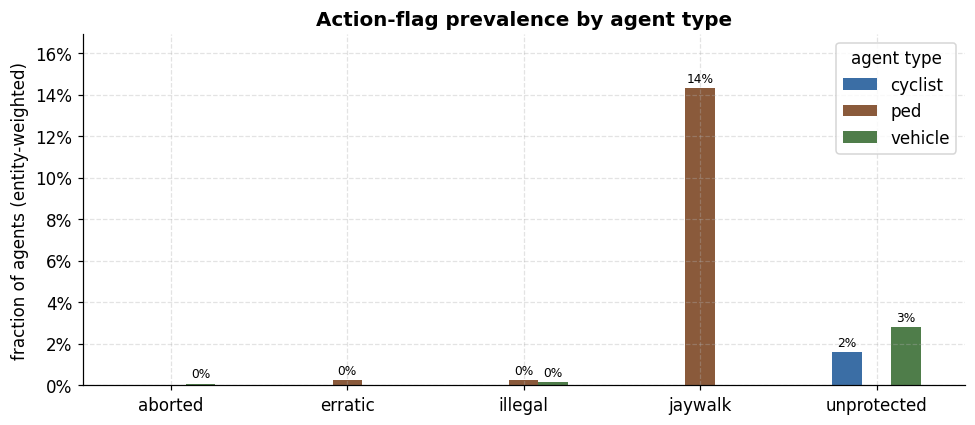

In [14]:
pivot = flag_df.pivot(index="flag", columns="agent type", values="rate")
fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(kind="bar", ax=ax, color=["#3b6ea5", "#8a5a3b", "#4f7d4a"])
ax.set_ylabel("fraction of agents (entity-weighted)")
ax.set_xlabel("")
ax.set_title("Action-flag prevalence by agent type")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=0)
# Annotate every bar with its rate; suppress empty labels for zero bars.
for container in ax.containers:
    labels = [f"{v:.0%}" if v else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2, fontsize=8)
# Give the labels headroom so they don't clip above the top of the axes.
ymax = pivot.values.max()
ax.set_ylim(0, ymax * 1.18)
plt.tight_layout()
plt.show()

## Agent × environment co-occurrence

A heatmap of clip counts for each `agent.type` × `env.type`
pairing. Use it to spot under-represented combinations
(e.g. cyclist + tunnel, pedestrian + roundabout) and the
densest scenarios.

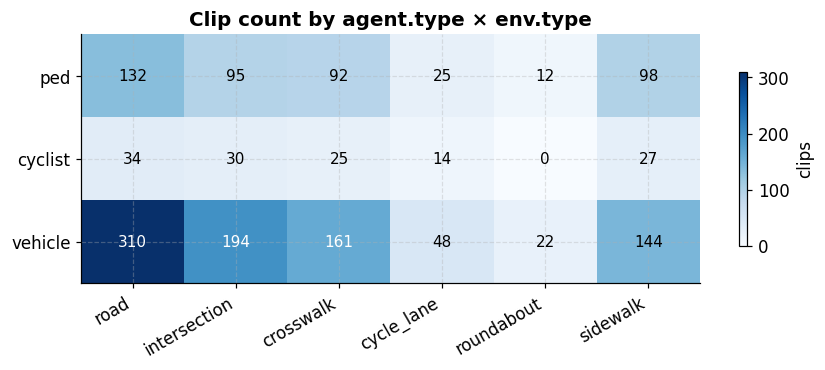

In [15]:
AGENTS_FOR_MATRIX = ["ped", "cyclist", "vehicle"]
ENVS_FOR_MATRIX = ["road", "intersection", "crosswalk", "cycle_lane", "roundabout", "sidewalk"]

matrix = np.zeros((len(AGENTS_FOR_MATRIX), len(ENVS_FOR_MATRIX)), dtype=int)
for i, a in enumerate(AGENTS_FOR_MATRIX):
    for j, e in enumerate(ENVS_FOR_MATRIX):
        matrix[i, j] = ds.count(f"agent.type = {a} and env.type = {e}")

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(matrix, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(ENVS_FOR_MATRIX)), labels=ENVS_FOR_MATRIX, rotation=30, ha="right")
ax.set_yticks(range(len(AGENTS_FOR_MATRIX)), labels=AGENTS_FOR_MATRIX)
ax.set_title("Clip count by agent.type × env.type")
threshold = matrix.max() / 2 if matrix.max() else 0
for i in range(len(AGENTS_FOR_MATRIX)):
    for j in range(len(ENVS_FOR_MATRIX)):
        ax.text(
            j, i, matrix[i, j],
            ha="center", va="center",
            color="white" if matrix[i, j] > threshold else "black",
            fontsize=10,
        )
fig.colorbar(im, ax=ax, shrink=0.7, label="clips")
plt.tight_layout()
plt.show()

## Scene density (agents per clip)

How crowded is a typical clip? Histogram of the agent count
in each clip's annotation tree. Pair it with the headline
counts above to filter for sparse vs dense scenarios.

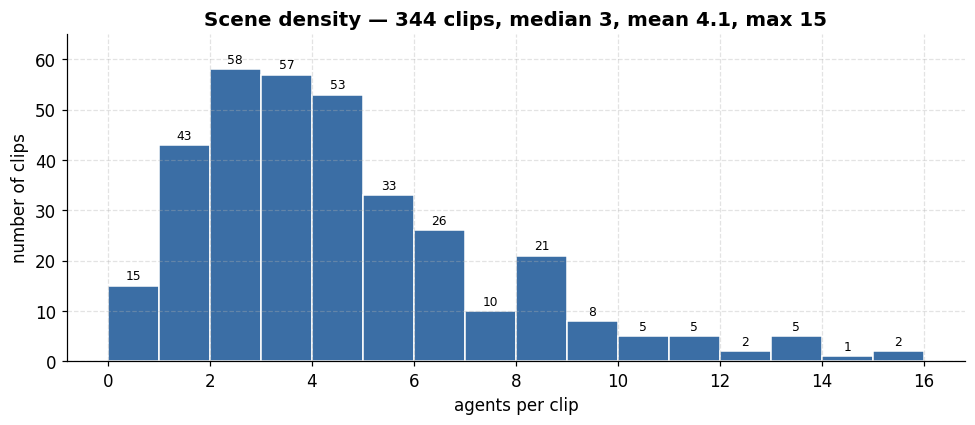

In [16]:
agent_counts = pd.Series(
    [len(seq.annotation.annotation.agents) for seq in ds],
    name="agents per clip",
)
max_count = int(agent_counts.max())
fig, ax = plt.subplots(figsize=(9, 4))
counts, bins, patches = ax.hist(
    agent_counts,
    bins=range(0, max_count + 2),
    color="#3b6ea5",
    edgecolor="white",
)
# Label each bin with its clip count; hide zero-count bins.
labels = [str(int(c)) if c else "" for c in counts]
ax.bar_label(patches, labels=labels, padding=2, fontsize=8)
# Headroom so labels don't bump the title.
ax.set_ylim(0, counts.max() * 1.12)
ax.set_xlabel("agents per clip")
ax.set_ylabel("number of clips")
ax.set_title(
    f"Scene density — {len(ds)} clips, "
    f"median {agent_counts.median():.0f}, "
    f"mean {agent_counts.mean():.1f}, "
    f"max {max_count}"
)
plt.tight_layout()
plt.show()